In [354]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from functools import reduce
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneOut, cross_val_score


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Overview #2
Prepares the input data for model training. It processes the summary statistics folder, which contains files for seven extracted features, and consolidates the data into a single DataFrame. The resulting DataFrame includes columns for Subject ID, Session ID, Trial ID, and Gesture (the target variable for prediction), while the remaining columns represent the summary statistics for all extracted features.

In [402]:
data_folder = os.path.join('..', 'PreprocessedDataML', 'SummaryStatistics')

# Initialize a df to add ALL FEATURES into one df
cumulative_df = None


for feature_file in sorted(os.listdir(data_folder)):
    feature = feature_file[:-9]

    df = pd.read_csv(os.path.join(data_folder, feature_file))

    # Rename columns related to left (L) and right (R) hands to include the feature name
    df = df.rename(columns={
        col: f"{feature}_{col}" for col in df.columns if col.startswith('L-') or col.startswith('R-')
    })

    # Merge DataFrames based on primary keys
    if cumulative_df is None:
        # First DataFrame becomes the base
        cumulative_df = df
    else:
        # Merge on primary keys + Gesture & Label to avoid duplicating them
        cumulative_df = pd.merge(
            cumulative_df, 
            df, 
            on=['SubID', 'SessionID', 'TrialID', 'Gesture', 'Label'], 
            how='inner'
        )

# Get the list of current columns
cols = list(cumulative_df.columns)

# Remove 'Gesture' from its current position
cols.remove('Gesture')
cols.remove('Label')

# Insert 'Gesture' at the 4th position after the subject, session, trial id
cols.insert(3, 'Gesture')

# Reorder the DataFrame
cumulative_df = cumulative_df[cols]
        

# Output csv to check layout of input dataframe
#if not os.path.exists(os.path.join(data_folder, 'Final.csv')):
    #cumulative_df.to_csv(os.path.join(data_folder, 'Final.csv'), header=True, index=False)

print(len(cumulative_df))

2083


In [403]:
# Convert Gesture text value to numeric
gesture_label_encoder = LabelEncoder()
gesture_encoded = gesture_label_encoder.fit_transform(cumulative_df['Gesture'])

cumulative_df['Gesture'] = gesture_encoded

# Display the mapping of original gestures to encoded labels
for index, label in enumerate(gesture_label_encoder.classes_):
    print(f"{index} → {label}")

0 → PanDown
1 → PanLeft
2 → PanRight
3 → PanUp
4 → RotBackX
5 → RotClockwiseY
6 → RotCounterY
7 → RotForwardX
8 → RotLeftZ
9 → RotRightZ
10 → ZoomIn
11 → ZoomOut


### Overview #3

Prepares data by separating into training and testing (with two participant selected).

#### Variables:
* data_df: Used for training/testing
* validation_df: Used to introduce the model to unseen data after training/testing; Two subject sessions

In [405]:
# Keep primary keys for reference
primary_keys = ['SubID', 'SessionID', 'TrialID']
primary_key_df = cumulative_df[primary_keys]  # Store primary keys separately

# Prepare test data
X = cumulative_df.drop(primary_keys + ['Gesture'], axis=1)  # All columns except 'Gesture' and primary keys
y = cumulative_df['Gesture']

In [406]:
random.seed(42)
# Train-Test Split with index tracking
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, cumulative_df.index,  # Tracking the original indices
    test_size=0.2,
    random_state=42
)

Select two participants from the test data

In [ ]:
# For reproducability
random.seed(42)

# Choose two subject sessions from X_test
random_indices = random.sample(range(len(X_test)), 2)
second_X_test = pd.DataFrame()
second_y_test = pd.DataFrame()

second_X_test = X_test.iloc[random_indices]
second_y_test = y_test.iloc[random_indices]

print(second_X_test.shape)

(2, 81)


### Overview #4

Random Forest Model.

* Implements a grid search for the best hyperparameters.
* Set up model.
* Train and test model.
* Print out reports and graphs of results.
* Check with validation dataset

In [ ]:
# Hyperparameters for grid search
grid = {
    'n_estimators': [200, 250, 300, 350],
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [6, 8, 10, 12, 14, 16, 18],
    'criterion' :['gini', 'entropy'],
    'random_state' : [42]
}

rf_cv = GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid, cv= 5)
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 12, 14, 16, 18],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [200, 250, 300, 350],
                         'random_state': [42]})

In [104]:
rf_cv.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'n_estimators': 250,
 'random_state': 42}

In [388]:
rf_model = RandomForestClassifier(
    n_estimators=300,    # Number of trees
    max_depth=14,      # Let trees grow fully
    random_state=42,
    max_features='log2',
    oob_score=True,
    min_samples_split=2,  
    criterion='entropy'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=14, max_features='log2',
                       n_estimators=300, oob_score=True, random_state=42)

In [389]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=gesture_label_encoder.classes_))

Accuracy: 0.8848920863309353
               precision    recall  f1-score   support

      PanDown       0.87      1.00      0.93        34
      PanLeft       0.92      0.89      0.91        38
     PanRight       0.95      0.91      0.93        43
        PanUp       0.90      0.95      0.92        37
     RotBackX       0.88      0.79      0.83        38
RotClockwiseY       0.89      0.97      0.93        32
  RotCounterY       0.86      0.86      0.86        29
  RotForwardX       0.91      0.77      0.83        39
     RotLeftZ       0.69      0.67      0.68        27
    RotRightZ       0.82      0.82      0.82        40
       ZoomIn       0.92      1.00      0.96        33
      ZoomOut       0.96      1.00      0.98        27

     accuracy                           0.88       417
    macro avg       0.88      0.89      0.88       417
 weighted avg       0.88      0.88      0.88       417



Second accuracy test but on two unseen data

In [400]:
second_y_pred = rf_model.predict(second_X_test)

# Get the unique classes in `second_y_test`
unique_classes = np.unique(second_y_test)

# Map them to class names from `gesture_label_encoder`
filtered_target_names = [gesture_label_encoder.classes_[i] for i in unique_classes]

print("Accuracy:", accuracy_score(second_y_test, second_y_pred))
print(classification_report(second_y_test, second_y_pred, target_names=filtered_target_names))

Accuracy: 1.0
              precision    recall  f1-score   support

     PanLeft       1.00      1.00      1.00         1
 RotCounterY       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [362]:
loo = LeaveOneOut()  # Leave-One-Out cross-validator

# Perform LOOCV and compute accuracy scores
loo_scores = cross_val_score(rf_model, X_train, y_train, cv=loo, scoring='accuracy')

# Print average LOOCV accuracy
print(f"LOOCV Accuracy: {np.mean(loo_scores):.4f}")

KeyboardInterrupt: 

<Figure size 1200x600 with 0 Axes>

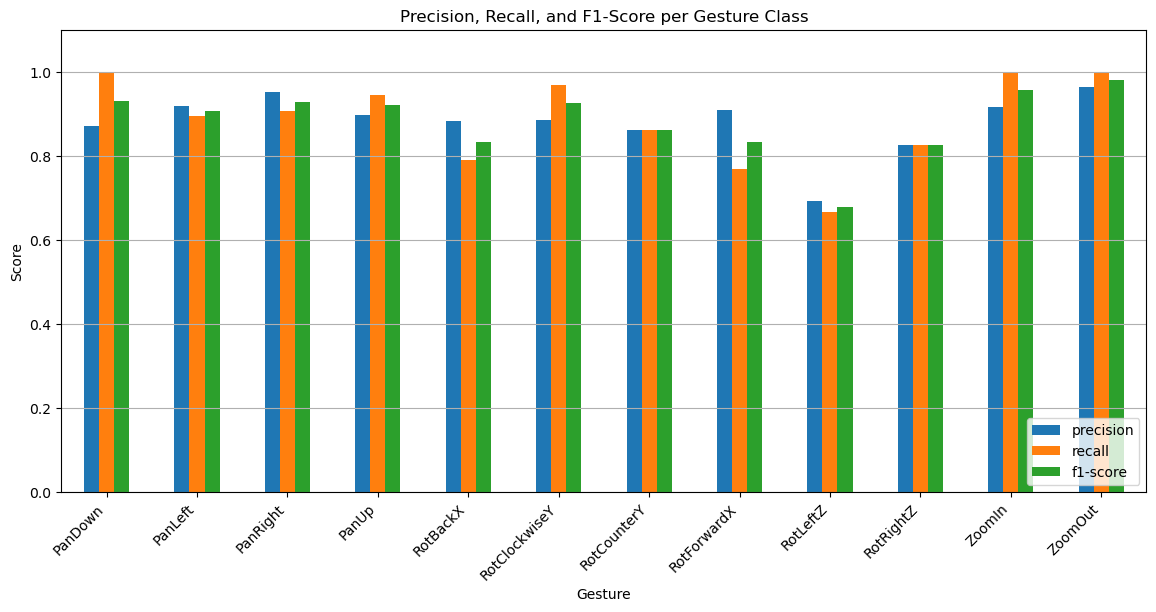

In [363]:
# Plotting precision, recall, and f1-score
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove accuracy, macro avg, and weighted avg rows
report_df = report_df.iloc[:-3, :]

# Set up figures
plt.figure(figsize=(12, 6))
ax = report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 6))

# Set x-tick positions and labels correctly
ax.set_xticks(range(len(gesture_label_encoder.classes_)))  # Assign numerical positions
ax.set_xticklabels(gesture_label_encoder.classes_, rotation=45, ha="right")  # Assign class labels

# Modify setup
plt.title("Precision, Recall, and F1-Score per Gesture Class")
plt.xlabel("Gesture")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.legend(loc='lower right')

plt.show()

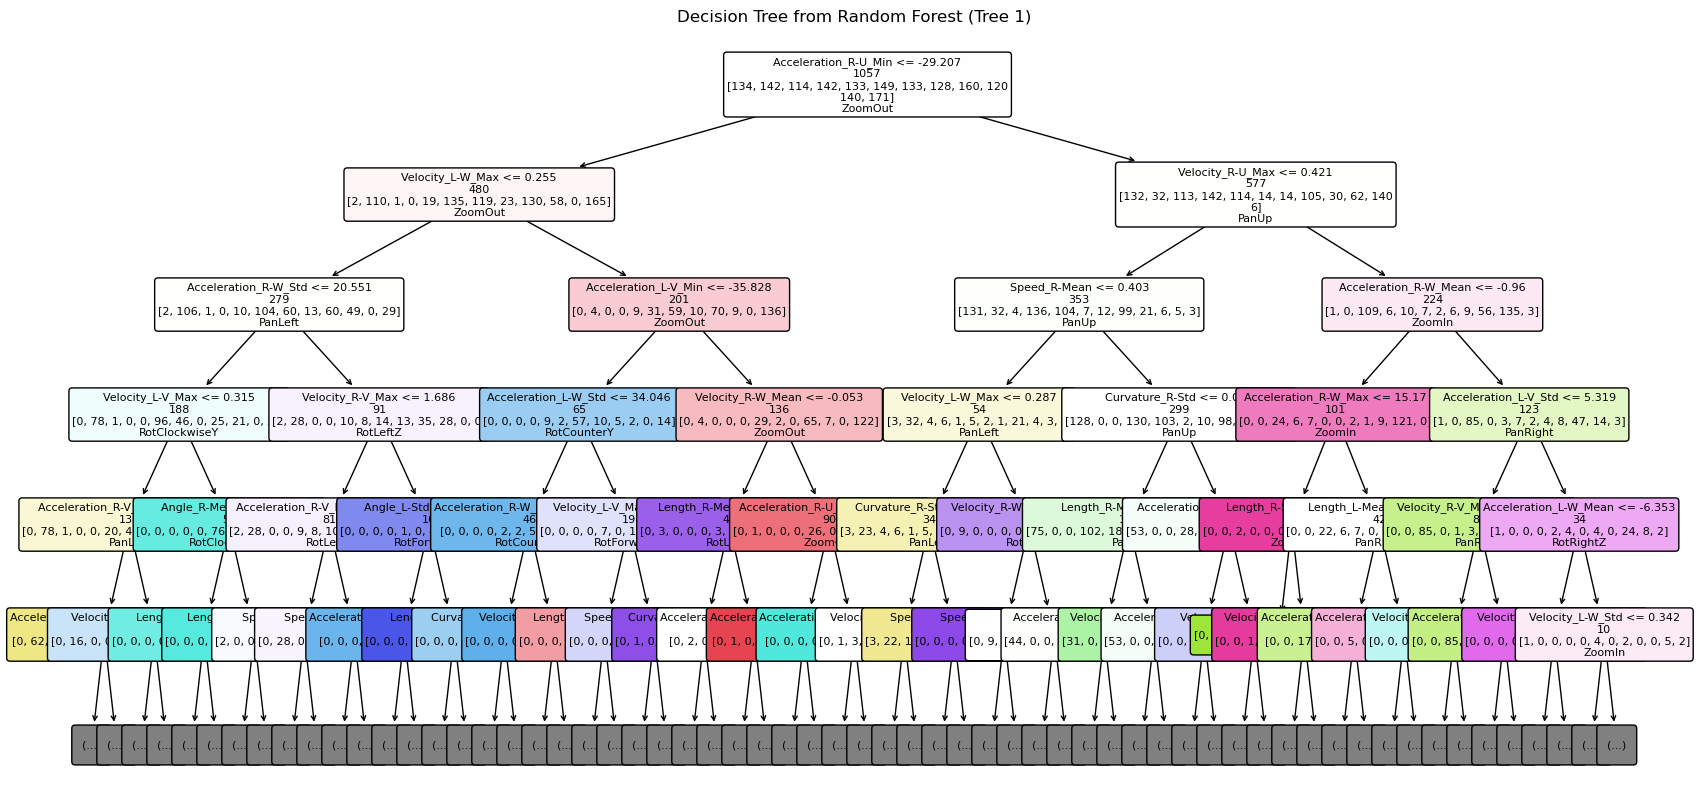

In [364]:
# Plotting a sample bootstrap tree
features = X.columns.tolist()

plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0], 
    feature_names=features,         
    class_names=gesture_label_encoder.classes_.tolist(),
    filled=True,
    rounded=True,
    max_depth=5,
    proportion=False,  # Set to False to avoid proportions inside nodes
    impurity=False,    # Removes Gini values
    label="none",       # Removes feature values
    fontsize=8
)
plt.title("Decision Tree from Random Forest (Tree 1)")
plt.show()


In [365]:
# Displaying list of feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Select the top 40 most important features
top_features_indices = np.argsort(importances)[-40:]  # Indices of top 40 features
top_importances = importances[top_features_indices]   # Their importances
top_feature_names = feature_names[top_features_indices]  # Corresponding feature names

for i in reversed(range(len(top_feature_names))):  # Reverse order (highest importance first)
    print(f"{top_feature_names[i]}: {top_importances[i]:.4f}")

Acceleration_R-U_Mean: 0.0442
Velocity_R-U_Mean: 0.0390
Velocity_R-U_Min: 0.0383
Acceleration_R-U_Min: 0.0381
Acceleration_R-U_Max: 0.0366
Velocity_R-V_Min: 0.0360
Acceleration_R-V_Mean: 0.0354
Acceleration_R-V_Max: 0.0344
Velocity_R-U_Max: 0.0327
Velocity_R-V_Max: 0.0309
Velocity_R-V_Mean: 0.0287
Acceleration_R-V_Min: 0.0266
Velocity_R-W_Mean: 0.0239
Acceleration_R-W_Mean: 0.0238
Acceleration_R-V_Std: 0.0227
Velocity_R-U_Std: 0.0212
Velocity_R-V_Std: 0.0204
Velocity_L-U_Mean: 0.0202
Acceleration_R-U_Std: 0.0202
Acceleration_L-U_Mean: 0.0186
Velocity_L-U_Max: 0.0182
Acceleration_L-U_Max: 0.0167
Velocity_L-U_Min: 0.0160
Velocity_R-W_Max: 0.0144
Acceleration_L-W_Mean: 0.0144
Acceleration_L-U_Min: 0.0143
Velocity_L-W_Mean: 0.0136
Acceleration_R-W_Max: 0.0126
Acceleration_R-W_Min: 0.0124
Velocity_R-W_Min: 0.0118
Velocity_L-V_Max: 0.0111
Acceleration_L-V_Mean: 0.0106
Velocity_L-V_Mean: 0.0106
Acceleration_L-V_Max: 0.0100
Acceleration_R-W_Std: 0.0081
Velocity_L-U_Std: 0.0080
Acceleration_L-U

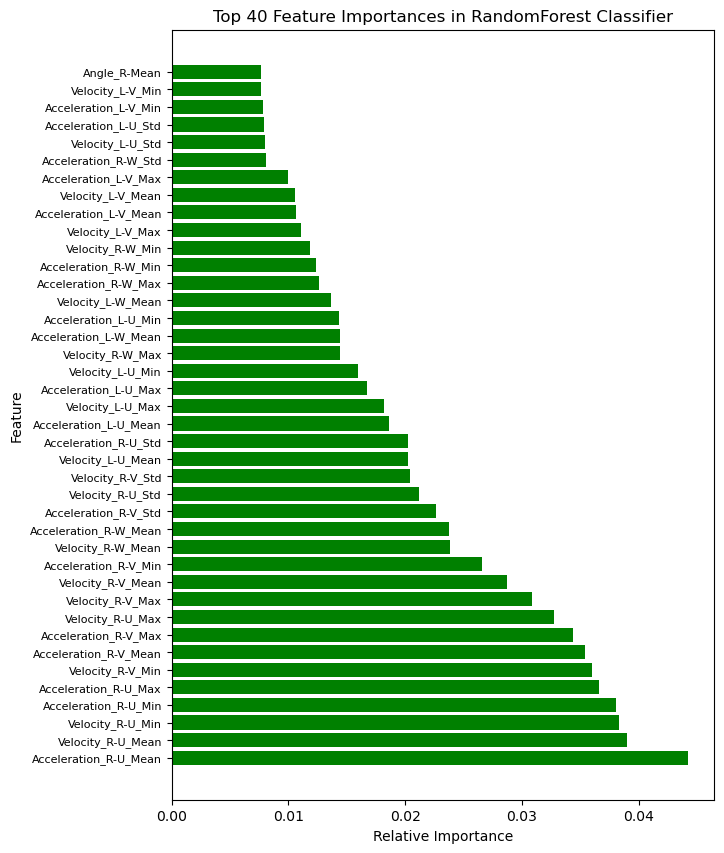

In [366]:
# Plotting only the top 40 feature importances
fig, ax = plt.subplots(figsize=(7, 10))  # Adjust figure size for better readability
ax.barh(range(len(top_importances)), top_importances, color='green')
ax.set_yticks(range(len(top_feature_names)))
ax.set_yticklabels(top_feature_names, fontsize=8)  # Adjust font size for readability
plt.title('Top 40 Feature Importances in RandomForest Classifier')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Flip the order so highest importance is at the top
plt.show()

<Figure size 1000x800 with 0 Axes>

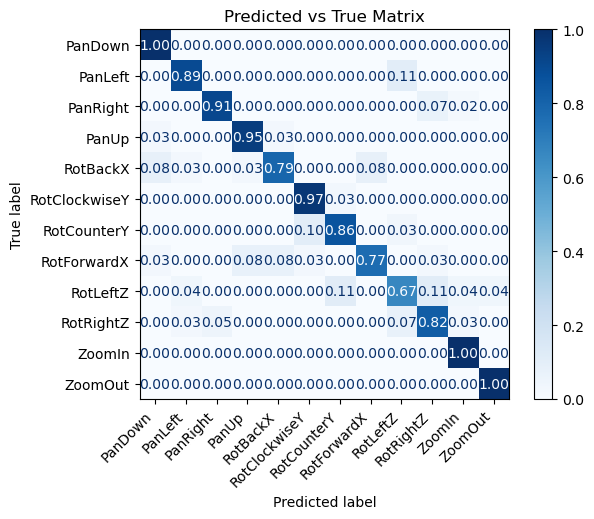

In [367]:
# Confusion matrix to display model predictions against true values
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_label_encoder.classes_)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='.2f')
plt.xticks(rotation=45, ha="right")
plt.title('Predicted vs True Matrix')
plt.show()

In [368]:
# Identifying trials where the model predicted incorrectly

misclassified_indices = (y_pred != y_test)

misclassified_original_indices = idx_test[misclassified_indices]

# Display Misclassified Rows with Primary Keys
misclassified_df = pd.DataFrame({
    'SubID': data_df.loc[misclassified_original_indices, 'SubID'].values,
    'SessionID': data_df.loc[misclassified_original_indices, 'SessionID'].values,
    'TrialID': data_df.loc[misclassified_original_indices, 'TrialID'].values,
    'Actual Gesture': gesture_label_encoder.inverse_transform(y_test[misclassified_indices]),
    'Predicted Gesture': gesture_label_encoder.inverse_transform(y_pred[misclassified_indices])
})

print(misclassified_df)

KeyError: '[1572, 1391, 1251] not in index'

In [369]:
# Make predictions on the validation set
y_validation_pred = rf_model.predict(X_validation)

#print(y_validation_pred)
#print(y_validation)

# Compute validation accuracy
val_accuracy = accuracy_score(y_validation, y_validation_pred)

# Print validation results
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nValidation Classification Report:\n", classification_report(y_validation, y_validation_pred))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Label


In [303]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [304]:
# Define the parameter grid
param_grid = {
    'max_depth': [6, 9, 12],  # Tree depth
    'learning_rate': [0.1, 0.2, 0.3, 0.4],  # Step size shrinkage
    'n_estimators': [200, 250, 300, 350],  # Number of boosting rounds
    'subsample': [0.8, 1],  # Fraction of samples per tree
    'colsample_bytree': [0.8, 1],  # Fraction of features per tree
    'reg_alpha': [.1, .2, .9, 1],
    'reg_lambda': [.1, .2, .9, 1]
}

xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y_train.unique()), random_state=42)

# Perform Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    xgb_model, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all CPU cores
    verbose=2  # Print progress
)

# Fit the GridSearch model
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 3072 candidates, totalling 9216 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=12,
                                     num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.1, 0.2, 0.3, 0.4],
                         'max_depth': [6, 9, 12],
                         'n_estimators': [200, 250, 300, 350],
                         'reg_alpha': [0.1, 0.2, 0.9, 1],
                         'reg_lambda': [0.1, 0.2, 0.9, 1],
                         'subsample': [0.8, 1]},
             scoring='accuracy', verbose=2)

In [306]:
best_params = grid_search.best_params_
print(best_params)

{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 350, 'reg_alpha': 0.1, 'reg_lambda': 0.9, 'subsample': 0.8}


In [326]:
# Set XGBoost parameters
params = {
    'objective': 'multi:softmax',  # For multi-class classification
    'num_class': len(gesture_label_encoder.classes_),  # Number of unique classes
    'eval_metric': ['mlogloss', 'merror'],  # Multi-class log loss
    'max_depth': 8,  # Maximum depth of trees
    'learning_rate': 0.3,  # Step size shrinkage
    'n_estimators': 500,  # Number of boosting rounds
    'reg_alpha': 0.08,
    'reg_lambda': .95,

    'random_state': 42
}

# Train the model
xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['mlogloss', 'merror'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_class=12, num_parallel_tree=None, ...)

In [327]:
# Make predictions
y_test_pred = xgb_model.predict(X_test)

# Compute accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.9059

Test Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        29
           1       0.92      0.92      0.92        37
           2       0.89      0.97      0.93        40
           3       0.93      0.93      0.93        43
           4       0.92      0.85      0.88        27
           5       0.96      0.96      0.96        28
           6       0.96      0.92      0.94        26
           7       0.88      0.80      0.84        35
           8       0.77      0.79      0.78        34
           9       0.85      0.80      0.82        35
          10       0.96      0.96      0.96        23
          11       1.00      0.97      0.99        36

    accuracy                           0.91       393
   macro avg       0.91      0.91      0.91       393
weighted avg       0.91      0.91      0.91       393



<Figure size 1200x600 with 0 Axes>

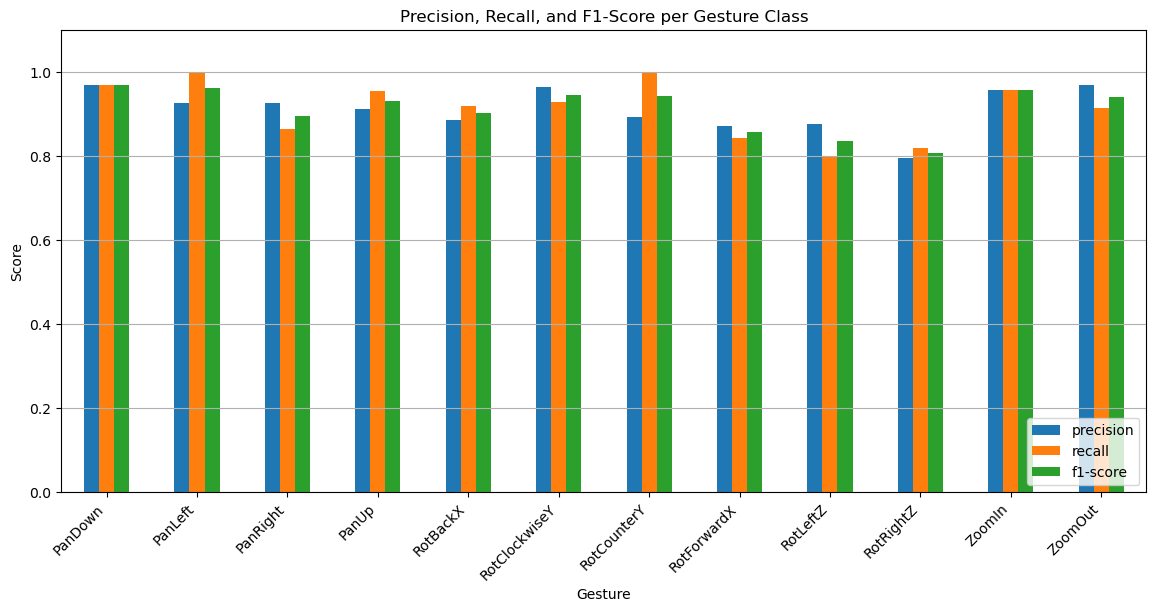

In [329]:
# Plotting precision, recall, and f1-score
report = classification_report(y_test_pred, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove accuracy, macro avg, and weighted avg rows
report_df = report_df.iloc[:-3, :]

# Set up figures
plt.figure(figsize=(12, 6))
ax = report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 6))

# Set x-tick positions and labels correctly
ax.set_xticks(range(len(gesture_label_encoder.classes_)))  # Assign numerical positions
ax.set_xticklabels(gesture_label_encoder.classes_, rotation=45, ha="right")  # Assign class labels

# Modify setup
plt.title("Precision, Recall, and F1-Score per Gesture Class")
plt.xlabel("Gesture")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.legend(loc='lower right')

plt.show()

In [330]:
# Displaying list of feature importances
importances = xgb_model.feature_importances_
feature_names = X.columns

# Select the top 40 most important features
top_features_indices = np.argsort(importances)[-40:]  # Indices of top 40 features
top_importances = importances[top_features_indices]   # Their importances
top_feature_names = feature_names[top_features_indices]  # Corresponding feature names

for i in reversed(range(len(top_feature_names))):  # Reverse order (highest importance first)
    print(f"{top_feature_names[i]}: {top_importances[i]:.4f}")

Label: 0.0893
Acceleration_R-V_Max: 0.0630
Acceleration_R-U_Min: 0.0507
Velocity_R-V_Min: 0.0473
Acceleration_L-V_Mean: 0.0405
Velocity_L-U_Max: 0.0319
Acceleration_R-V_Min: 0.0293
Curvature_R-Std: 0.0284
Velocity_R-U_Std: 0.0239
Acceleration_L-U_Mean: 0.0234
Acceleration_R-U_Std: 0.0231
Length_R-Max: 0.0230
Acceleration_R-W_Min: 0.0226
Acceleration_R-U_Max: 0.0224
Acceleration_L-W_Mean: 0.0206
Acceleration_R-V_Mean: 0.0193
Velocity_R-W_Max: 0.0187
Length_L-Mean: 0.0175
Curvature_R-Mean: 0.0173
Velocity_R-U_Max: 0.0160
Acceleration_L-U_Std: 0.0155
Angle_R-Mean: 0.0154
Acceleration_L-U_Min: 0.0149
Acceleration_R-W_Mean: 0.0144
Velocity_R-W_Min: 0.0140
Curvature_R-Max: 0.0135
Acceleration_R-U_Mean: 0.0129
Acceleration_L-V_Min: 0.0126
Length_R-Mean: 0.0126
Acceleration_L-W_Max: 0.0123
Velocity_R-U_Min: 0.0115
Velocity_R-U_Mean: 0.0114
Acceleration_L-W_Min: 0.0108
Acceleration_L-U_Max: 0.0098
Angle_R-Max: 0.0096
Speed_L-Max: 0.0089
Velocity_R-V_Max: 0.0084
Length_L-Std: 0.0083
Length_R-Min

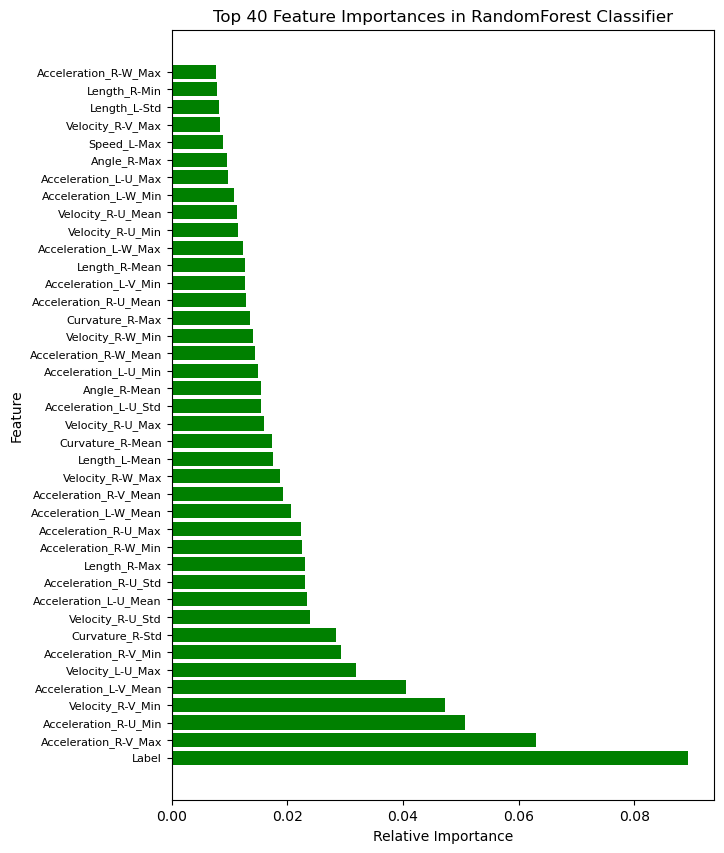

In [331]:
# Plotting only the top 40 feature importances
fig, ax = plt.subplots(figsize=(7, 10))  # Adjust figure size for better readability
ax.barh(range(len(top_importances)), top_importances, color='green')
ax.set_yticks(range(len(top_feature_names)))
ax.set_yticklabels(top_feature_names, fontsize=8)  # Adjust font size for readability
plt.title('Top 40 Feature Importances in RandomForest Classifier')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Flip the order so highest importance is at the top
plt.show()

<Figure size 1000x800 with 0 Axes>

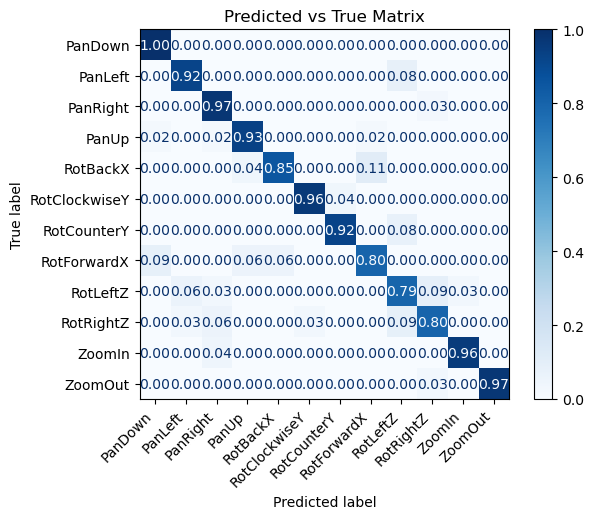

In [332]:
# Confusion matrix to display model predictions against true values
cm = confusion_matrix(y_test, y_test_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_label_encoder.classes_)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='.2f')
plt.xticks(rotation=45, ha="right")
plt.title('Predicted vs True Matrix')
plt.show()

In [333]:
# Make predictions on the validation set
y_validation_pred = xgb_model.predict(X_validation)

#print(y_validation_pred)
#print(y_validation)

# Compute validation accuracy
val_accuracy = accuracy_score(y_validation, y_validation_pred)

# Print validation results
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nValidation Classification Report:\n", classification_report(y_validation, y_validation_pred))

Validation Accuracy: 0.8417

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      1.00      1.00        10
           2       1.00      0.90      0.95        10
           3       0.91      1.00      0.95        10
           4       0.77      1.00      0.87        10
           5       1.00      0.30      0.46        10
           6       0.67      1.00      0.80        10
           7       1.00      0.60      0.75        10
           8       0.64      0.70      0.67        10
           9       0.55      0.60      0.57        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10

    accuracy                           0.84       120
   macro avg       0.87      0.84      0.83       120
weighted avg       0.87      0.84      0.83       120

